# 3D RRT Motion Planner for UAV
## Pure Python Implementation with Interactive Visualization

A self-contained Rapidly-exploring Random Tree (RRT) planner that finds collision-free 3D flight trajectories for UAVs inside bounded airspace with cuboid obstacles.

### Features
- Goal-biased uniform sampling (10% bias toward goal)
- Modular steer local planner
- Geometric axis-aligned bounding-box collision checking with 1.5 m safety buffer
- Cumulative cost tracking
- Full matplotlib 3D visualization

## 1. Import Libraries

In [1]:
import math
import random
import copy
import time

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

# Enable inline plotting in Jupyter Notebook
%matplotlib inline

print("✅ Libraries imported successfully!")
print("   - math, random, copy, time")
print("   - matplotlib, numpy, mpl_toolkits")

✅ Libraries imported successfully!
   - math, random, copy, time
   - matplotlib, numpy, mpl_toolkits


## 2. Airspace Configuration

Define the bounded airspace, obstacles, and RRT parameters.

In [2]:
# ============================================================
#  AIRSPACE CONFIGURATION
# ============================================================
X_MAX = 100.0   # Width of the airspace (meters)
Y_MAX = 100.0   # Depth of the airspace (meters)
Z_MAX = 30.0    # Maximum altitude allowed (meters)

# ============================================================
#  RRT* & MANEUVER SPACE PARAMETERS
# ============================================================
STEP_SIZE        = 6.0    # Travel distance per maneuver/step (meters)
GOAL_SAMPLE_RATE = 0.15   # Probability of sampling directly towards the goal (15%)
GOAL_THRESHOLD   = 6.0    # Distance threshold to clear the goal (meters)
MAX_ITER         = 2000   # Maximum planning iterations
INFLATION        = 1.5    # Obstacle safety buffer inflation (meters)
SEARCH_RADIUS    = 15.0   # Search radius for RRT* neighbor queries (meters)

# ============================================================
#  KINEMATIC STEERING BOUNDS (Nominal limits for scaling)
# ============================================================
MAX_YAW_CHANGE  = math.radians(35.0)  # Nominal max yaw rate per step
MAX_PITCH_ANGLE = math.radians(20.0)  # Nominal max pitch rate per step

# ============================================================
#  OBSTACLES (Format: x_min, y_min, z_min, x_max, y_max, z_max)
# ============================================================
OBSTACLES = [
    (20.0, 20.0,  0.0, 40.0, 40.0, 25.0),   # Building A
    (60.0, 50.0,  0.0, 75.0, 70.0, 30.0),   # Building B
    (45.0, 10.0,  0.0, 55.0, 60.0, 15.0),   # Building C
]

# ============================================================
#  START & GOAL NODES CONFIGURATION
# ============================================================
START_POS = (5.0, 5.0, 2.0)     # (x, y, z) start position
GOAL_POS  = (90.0, 90.0, 20.0)  # (x, y, z) goal position
START_PSI = math.radians(45.0)  # Initial UAV heading (45 degrees / North-East)

# ============================================================
#  PRINT CONFIGURATION SUMMARY
# ============================================================
print("="*55)
print(" UAV RRT* PLANNER CONFIGURATION (AGILE MANEUVER SPACE)")
print("="*55)
print(f"  Airspace Limits  : {X_MAX} x {Y_MAX} x {Z_MAX} m")
print(f"  Obstacle Count   : {len(OBSTACLES)} cuboids (inflation: {INFLATION} m)")
print(f"  Max Iterations   : {MAX_ITER}")
print(f"  Step Size        : {STEP_SIZE} m")
print(f"  Nominal Max Yaw  : {math.degrees(MAX_YAW_CHANGE):.1f}°/step")
print(f"  Nominal Max Pitch: {math.degrees(MAX_PITCH_ANGLE):.1f}°/step")
print(f"  Start Position   : {START_POS}")
print(f"  Goal Position    : {GOAL_POS}")
print("="*55)

 UAV RRT* PLANNER CONFIGURATION (AGILE MANEUVER SPACE)
  Airspace Limits  : 100.0 x 100.0 x 30.0 m
  Obstacle Count   : 3 cuboids (inflation: 1.5 m)
  Max Iterations   : 2000
  Step Size        : 6.0 m
  Nominal Max Yaw  : 35.0°/step
  Nominal Max Pitch: 20.0°/step
  Start Position   : (5.0, 5.0, 2.0)
  Goal Position    : (90.0, 90.0, 20.0)


## 3. Node Class

A single vertex in the RRT search tree.

In [3]:
class Node:
    """
    Represents a single vertex/state in the RRT* search tree.
    Stores coordinate positions and heading orientations for the fixed-wing UAV.
    """
    def __init__(self, x, y, z, psi=0.0):
        self.x      = float(x)
        self.y      = float(y)
        self.z      = float(z)
        self.psi    = float(psi)  # UAV heading/yaw angle (radians)
        self.parent = None        # Reference link to parent Node
        self.cost   = 0.0         # Accumulated trajectory cost from Start to this Node (meters)

    def pos(self):
        """Returns position coordinate as a tuple (x, y, z)."""
        return (self.x, self.y, self.z)

    def __repr__(self):
        return (f"Node(x={self.x:.2f}, y={self.y:.2f}, z={self.z:.2f}, "
                f"psi={math.degrees(self.psi):.1f}°, cost={self.cost:.2f}m)")

# Test the Node class
test_node = Node(10.0, 20.0, 5.0, psi=math.radians(45.0))
print("✅ Node class is ready!")
print(f"   Sample node: {test_node}")

✅ Node class is ready!
   Sample node: Node(x=10.00, y=20.00, z=5.00, psi=45.0°, cost=0.00m)


## 4. Core RRT Functions

### 4.1 Distance Calculation

In [4]:
def hitung_jarak(node_a, node_b):
    """Computes the 3D Euclidean distance between two nodes."""
    return math.sqrt(
        (node_a.x - node_b.x) ** 2 +
        (node_a.y - node_b.y) ** 2 +
        (node_a.z - node_b.z) ** 2
    )

def get_random_node(goal):
    """
    Samples a target node with goal biasing.
    Returns the Goal node with probability GOAL_SAMPLE_RATE, 
    otherwise returns a uniformly sampled random node within the airspace.
    """
    if random.random() < GOAL_SAMPLE_RATE:
        return Node(goal.x, goal.y, goal.z)
    return Node(
        random.uniform(0.0, X_MAX),
        random.uniform(0.0, Y_MAX),
        random.uniform(0.0, Z_MAX),
    )

def get_nearest_node_id(node_list, rnd_node):
    """Finds and returns the index of the nearest node in node_list to rnd_node."""
    distances = [hitung_jarak(n, rnd_node) for n in node_list]
    return distances.index(min(distances))

# Test functions
n1 = Node(0, 0, 0)
n2 = Node(3, 4, 0)
print("✅ Distance and sampling helper functions are ready!")
print(f"   Calculated distance ((0,0,0) -> (3,4,0)) = {hitung_jarak(n1, n2):.2f} m (Expected: 5.00)")

✅ Distance and sampling helper functions are ready!
   Calculated distance ((0,0,0) -> (3,4,0)) = 5.00 m (Expected: 5.00)


### 5 Random Node Sampling with Goal Bias

In [6]:
def steer(from_node, to_node, step=STEP_SIZE):
    """
    Geometric kinematic steering function used to estimate connections.
    Clamps yaw change to MAX_YAW_CHANGE and pitch change to MAX_PITCH_ANGLE.
    """
    dx = to_node.x - from_node.x
    dy = to_node.y - from_node.y
    dz = to_node.z - from_node.z
    dist_3d = math.sqrt(dx**2 + dy**2 + dz**2)

    if dist_3d < 1e-6:
        new_node = Node(to_node.x, to_node.y, to_node.z, psi=from_node.psi)
        new_node.parent = from_node
        new_node.cost = from_node.cost
        return new_node

    desired_psi   = math.atan2(dy, dx)
    dist_2d       = math.sqrt(dx**2 + dy**2)
    desired_pitch = math.atan2(dz, dist_2d) if dist_2d > 1e-6 else math.copysign(math.pi/2, dz)

    # Apply Yaw Limit
    yaw_error = desired_psi - from_node.psi
    yaw_error = (yaw_error + math.pi) % (2 * math.pi) - math.pi  # Normalize to [-pi, pi]

    if abs(yaw_error) > MAX_YAW_CHANGE:
        actual_yaw_change = math.copysign(MAX_YAW_CHANGE, yaw_error)
    else:
        actual_yaw_change = yaw_error

    new_psi = from_node.psi + actual_yaw_change
    new_psi = (new_psi + math.pi) % (2 * math.pi) - math.pi

    # Apply Pitch Limit
    if abs(desired_pitch) > MAX_PITCH_ANGLE:
        new_pitch = math.copysign(MAX_PITCH_ANGLE, desired_pitch)
    else:
        new_pitch = desired_pitch

    actual_step = min(step, dist_3d)
    new_x = from_node.x + actual_step * math.cos(new_pitch) * math.cos(new_psi)
    new_y = from_node.y + actual_step * math.cos(new_pitch) * math.sin(new_psi)
    new_z = from_node.z + actual_step * math.sin(new_pitch)

    new_node = Node(new_x, new_y, new_z, psi=new_psi)
    new_node.parent = from_node
    new_node.cost   = from_node.cost + hitung_jarak(from_node, new_node)
    return new_node


def generate_primitives(from_node, step_size):
    """
    Generates candidate next nodes based on the UAV's Agile Maneuver Space.
    Scales dynamically based on global MAX_YAW_CHANGE and MAX_PITCH_ANGLE parameters.
    """
    candidates = []
    
    # Maneuver ratios relative to nominal yaw and pitch limits
    # (Maneuver Name, Yaw Multiplier, Pitch Multiplier)
    maneuver_ratios = [
        # --- Steady Trim States ---
        ("Steady Cruise Straight",       0.0,   0.0),
        ("Standard Left Turn",          -0.6,   0.0),
        ("Standard Right Turn",          0.6,   0.0),
        ("Standard Gentle Climb",        0.0,   0.5),
        ("Standard Gentle Descent",      0.0,  -0.5),
        
        # --- Agile Maneuvers (Paper Concept: Aerobatics) ---
        ("Knife-Edge Sharp Turn Left",  -1.7,   0.0), # Extreme roll angle (knife-edge) for tight turns
        ("Knife-Edge Sharp Turn Right",  1.7,   0.0), # Extreme roll angle (knife-edge) for tight turns
        ("Agile Climb (Aggressive)",     0.0,   1.6), # Rapid vertical climb
        ("Agile Dive (Aggressive)",      0.0,  -1.6), # Rapid vertical dive
        ("Agile Climbing Left Turn",    -1.1,   0.8), # Combined banking climb
        ("Agile Climbing Right Turn",    1.1,   0.8), # Combined banking climb
    ]
    
    for name, yaw_mult, pitch_mult in maneuver_ratios:
        dyaw = yaw_mult * MAX_YAW_CHANGE
        dpitch = pitch_mult * MAX_PITCH_ANGLE
        
        # Compute new heading orientation
        new_psi = from_node.psi + dyaw
        new_psi = (new_psi + math.pi) % (2 * math.pi) - math.pi  # Normalize to [-pi, pi]
        
        # Compute target position coordinates
        new_x = from_node.x + step_size * math.cos(dpitch) * math.cos(new_psi)
        new_y = from_node.y + step_size * math.cos(dpitch) * math.sin(new_psi)
        new_z = from_node.z + step_size * math.sin(dpitch)
        
        # Keep inside airspace boundaries
        new_x = max(0.0, min(X_MAX, new_x))
        new_y = max(0.0, min(Y_MAX, new_y))
        new_z = max(0.0, min(Z_MAX, new_z))
        
        candidate = Node(new_x, new_y, new_z, psi=new_psi)
        candidate.parent = from_node
        
        dist = math.sqrt((new_x - from_node.x)**2 + (new_y - from_node.y)**2 + (new_z - from_node.z)**2)
        candidate.cost = from_node.cost + dist
        
        candidates.append((candidate, name))
        
    return candidates

print("✅ Kinematic Steering and Agile Maneuver Space primitives defined!")

✅ Kinematic Steering and Agile Maneuver Space primitives defined!


### 6 Collision detection

In [7]:
def _point_in_inflated_box(x, y, z, box, buffer=INFLATION):
    """
    Returns True if coordinates (x, y, z) are inside the obstacle box
    expanded by the safety margin buffer.
    """
    x_min, y_min, z_min, x_max, y_max, z_max = box
    return (
        (x_min - buffer) <= x <= (x_max + buffer) and
        (y_min - buffer) <= y <= (y_max + buffer) and
        (z_min - buffer) <= z <= (z_max + buffer)
    )

def check_collision(from_node, to_node, obstacles=OBSTACLES):
    """
    Returns True if the straight-line segment from from_node to to_node
    is completely collision-free, checking points sampled at 0.5m intervals.
    """
    dist  = hitung_jarak(from_node, to_node)
    steps = max(2, int(dist / 0.5))

    for i in range(steps + 1):
        t = i / steps
        x = from_node.x + (to_node.x - from_node.x) * t
        y = from_node.y + (to_node.y - from_node.y) * t
        z = from_node.z + (to_node.z - from_node.z) * t
        for box in obstacles:
            if _point_in_inflated_box(x, y, z, box):
                return False  # Collision detected

    return True  # Path is clean

def is_node_valid(node, obstacles=OBSTACLES):
    """Returns True if the node is in free space (outside all safety zones)."""
    for box in obstacles:
        if _point_in_inflated_box(node.x, node.y, node.z, box):
            return False
    return True

print("✅ Collision detection module is ready!")

✅ Collision detection module is ready!


### RRT* Helper Function

In [8]:
def extract_path(goal_node):
    """Traces parent nodes backwards from the goal to start, returning a list of coords."""
    path = []
    node = goal_node
    while node is not None:
        path.append((node.x, node.y, node.z))
        node = node.parent
    path.reverse()
    return path

def update_descendants_cost(parent_node, node_list):
    """Recursively updates the costs of children nodes when parent cost changes."""
    for node in node_list:
        if node.parent is parent_node:
            node.cost = parent_node.cost + hitung_jarak(parent_node, node)
            update_descendants_cost(node, node_list)

def get_near_nodes(node_list, new_node, radius=SEARCH_RADIUS):
    """Retrieves all tree nodes located within the given SEARCH_RADIUS to new_node."""
    return [
        node for node in node_list
        if hitung_jarak(node, new_node) <= radius
    ]

print("✅ RRT* helper functions are ready!")

✅ RRT* helper functions are ready!


### Agile Maneuver Space RRT Driver

In [9]:
def plan_rrt_star(start, goal, seed=None, verbose=True):
    """
    Agile Maneuver-Space Path Planner for fixed-wing UAV.
    Explores airspace via dynamically-scaled aerobatic/trim motion primitives.
    """
    if seed is not None:
        random.seed(seed)

    # Validate if start node starts in collision-free space
    if not is_node_valid(start):
        print("❌ ERROR: START position resides in an obstacle safety zone!")
        return [], None

    node_list      = [start]
    best_goal_node = None
    min_goal_cost  = float('inf')
    start_time     = time.time()

    for i in range(MAX_ITER):
        # 1. SAMPLE random target node
        rnd = get_random_node(goal)

        # 2. NEAREST node in tree
        nearest_id = get_nearest_node_id(node_list, rnd)
        nearest    = node_list[nearest_id]

        # 3. MANEUVER SELECTION (Agile Motion Primitives)
        candidates = generate_primitives(nearest, STEP_SIZE)
        best_candidate = None
        min_dist_to_rnd = float('inf')

        for candidate, name in candidates:
            # Check if this maneuver primitive is collision-free
            if check_collision(nearest, candidate):
                # Choose the candidate that drives closest to the sample point
                dist_to_rnd = hitung_jarak(candidate, rnd)
                if dist_to_rnd < min_dist_to_rnd:
                    min_dist_to_rnd = dist_to_rnd
                    best_candidate = candidate

        # Skip iteration if no safe maneuver from the library is available
        if best_candidate is None:
            continue

        # Add the selected valid maneuver to the tree
        node_list.append(best_candidate)

        # 4. GOAL TEST
        if hitung_jarak(best_candidate, goal) <= GOAL_THRESHOLD:
            # Verify if direct path from final primitive node to goal is clear
            if check_collision(best_candidate, goal):
                goal_cost = best_candidate.cost + hitung_jarak(best_candidate, goal)
                if goal_cost < min_goal_cost:
                    min_goal_cost = goal_cost
                    # Create the final goal node connected to our tree
                    best_goal_node = Node(goal.x, goal.y, goal.z, psi=best_candidate.psi)
                    best_goal_node.parent = best_candidate
                    best_goal_node.cost   = goal_cost
                    
                    if verbose:
                        print(f"  🎯 Iteration {i+1:4d}: Goal found! Cost = {goal_cost:.2f} m")

    elapsed = time.time() - start_time

    if best_goal_node is not None:
        node_list.append(best_goal_node)
        path = extract_path(best_goal_node)
        if verbose:
            print("\n" + "="*55)
            print("  ✅ MOTION PLANNING SUCCESSFUL!")
            print(f"     Path cost         : {best_goal_node.cost:.2f} m")
            print(f"     Total Waypoints   : {len(path)}")
            print(f"     Tree Size (Nodes) : {len(node_list)}")
            print(f"     Computation Time  : {elapsed:.3f} seconds")
            print("="*55)
        return node_list, path
    else:
        if verbose:
            print(f"\n❌ PLANNING FAILED: Goal not reached in {MAX_ITER} iterations.")
            print("   Try increasing MAX_ITER or STEP_SIZE.")
        return node_list, None

print("✅ Main RRT planner driver is ready!")

✅ Main RRT planner driver is ready!


### Obstacle And Safety Buffer Visualization

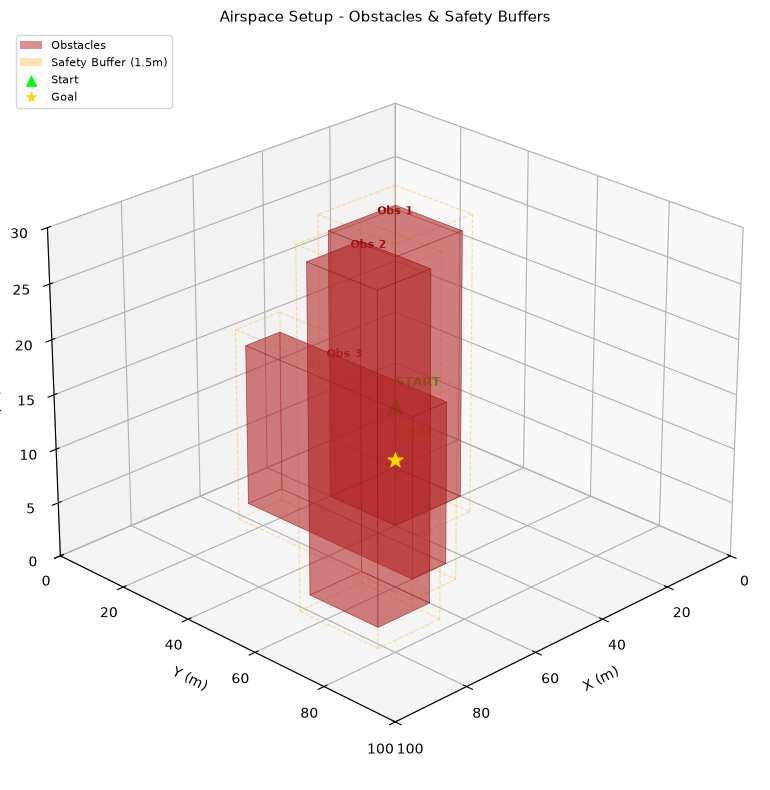

In [10]:
def draw_cuboid(ax, box, color='firebrick', alpha=0.3, label=None):
    """Draws a 3D obstacle block on the Matplotlib plot."""
    x_min, y_min, z_min, x_max, y_max, z_max = box
    corners = np.array([
        [x_min, y_min, z_min], [x_max, y_min, z_min],
        [x_max, y_max, z_min], [x_min, y_max, z_min],
        [x_min, y_min, z_max], [x_max, y_min, z_max],
        [x_max, y_max, z_max], [x_min, y_max, z_max],
    ])
    faces = [
        [corners[0], corners[1], corners[2], corners[3]],  # Bottom
        [corners[4], corners[5], corners[6], corners[7]],  # Top
        [corners[0], corners[1], corners[5], corners[4]],  # Front
        [corners[2], corners[3], corners[7], corners[6]],  # Back
        [corners[0], corners[3], corners[7], corners[4]],  # Left
        [corners[1], corners[2], corners[6], corners[5]],  # Right
    ]
    poly = Poly3DCollection(faces, alpha=alpha, facecolor=color, edgecolor='darkred', linewidth=0.5)
    ax.add_collection3d(poly)

def draw_inflated_cuboid(ax, box, buffer=INFLATION):
    """Draws a dashed wireframe showing the obstacle safety buffer zone."""
    x_min, y_min, z_min, x_max, y_max, z_max = box
    ib = buffer
    ix_min, iy_min, iz_min = x_min - ib, y_min - ib, z_min - ib
    ix_max, iy_max, iz_max = x_max + ib, y_max + ib, z_max + ib

    for xs, ys, zs in [
        ([ix_min, ix_max], [iy_min, iy_min], [iz_min, iz_min]),
        ([ix_min, ix_max], [iy_max, iy_max], [iz_min, iz_min]),
        ([ix_min, ix_max], [iy_min, iy_min], [iz_max, iz_max]),
        ([ix_min, ix_max], [iy_max, iy_max], [iz_max, iz_max]),
        ([ix_min, ix_min], [iy_min, iy_max], [iz_min, iz_min]),
        ([ix_max, ix_max], [iy_min, iy_max], [iz_min, iz_min]),
        ([ix_min, ix_min], [iy_min, iy_max], [iz_max, iz_max]),
        ([ix_max, ix_max], [iy_min, iy_max], [iz_max, iz_max]),
        ([ix_min, ix_min], [iy_min, iy_min], [iz_min, iz_max]),
        ([ix_max, ix_max], [iy_min, iy_min], [iz_min, iz_max]),
        ([ix_min, ix_min], [iy_max, iy_max], [iz_min, iz_max]),
        ([ix_max, ix_max], [iy_max, iy_max], [iz_min, iz_max]),
    ]:
        ax.plot(xs, ys, zs, color='orange', alpha=0.35, linewidth=0.8, linestyle='--')

# Plot airspace overview
fig = plt.figure(figsize=(11, 8))
ax  = fig.add_subplot(111, projection='3d')

# Draw obstacles
for idx, obs in enumerate(OBSTACLES):
    draw_cuboid(ax, obs, color='firebrick', alpha=0.35)
    draw_inflated_cuboid(ax, obs)
    cx = (obs[0] + obs[3]) / 2
    cy = (obs[1] + obs[4]) / 2
    cz = obs[5] + 1.5
    ax.text(cx, cy, cz, f'Obs {idx+1}', fontsize=8, ha='center', color='darkred', fontweight='bold')

# Plot Start & Goal
sx, sy, sz = START_POS
gx, gy, gz = GOAL_POS
ax.scatter([sx], [sy], [sz], c='lime', s=120, zorder=5, marker='^', label='Start')
ax.scatter([gx], [gy], [gz], c='gold', s=120, zorder=5, marker='*', label='Goal')
ax.text(sx, sy, sz + 2, 'START', fontsize=9, color='lime', fontweight='bold')
ax.text(gx, gy, gz + 2, 'GOAL',  fontsize=9, color='gold', fontweight='bold')

# Layout options
ax.set_xlim(0, X_MAX); ax.set_ylim(0, Y_MAX); ax.set_zlim(0, Z_MAX)
ax.set_xlabel('X (m)'); ax.set_ylabel('Y (m)'); ax.set_zlabel('Z (m)')
ax.set_title('Airspace Setup - Obstacles & Safety Buffers', fontsize=11)
legend_elements = [
    mpatches.Patch(facecolor='firebrick', alpha=0.5, label='Obstacles'),
    mpatches.Patch(facecolor='orange',    alpha=0.3, label=f'Safety Buffer ({INFLATION}m)'),
    plt.Line2D([0],[0], marker='^', color='w', markerfacecolor='lime', markersize=10, label='Start'),
    plt.Line2D([0],[0], marker='*', color='w', markerfacecolor='gold', markersize=12, label='Goal'),
]
ax.legend(handles=legend_elements, loc='upper left', fontsize=8)
ax.view_init(elev=25, azim=45)
plt.tight_layout()
plt.show()

## 10. Run Planner And Visuaization of 3D Trajectory

🚀 Running Agile Motion Planner...
   Start : Node(x=5.00, y=5.00, z=2.00, psi=45.0°, cost=0.00m)
   Goal  : Node(x=90.00, y=90.00, z=20.00, psi=0.0°, cost=0.00m)

  🎯 Iteration   64: Goal found! Cost = 141.64 m
  🎯 Iteration  504: Goal found! Cost = 140.77 m

  ✅ MOTION PLANNING SUCCESSFUL!
     Path cost         : 140.77 m
     Total Waypoints   : 25
     Tree Size (Nodes) : 1966
     Computation Time  : 1.376 seconds


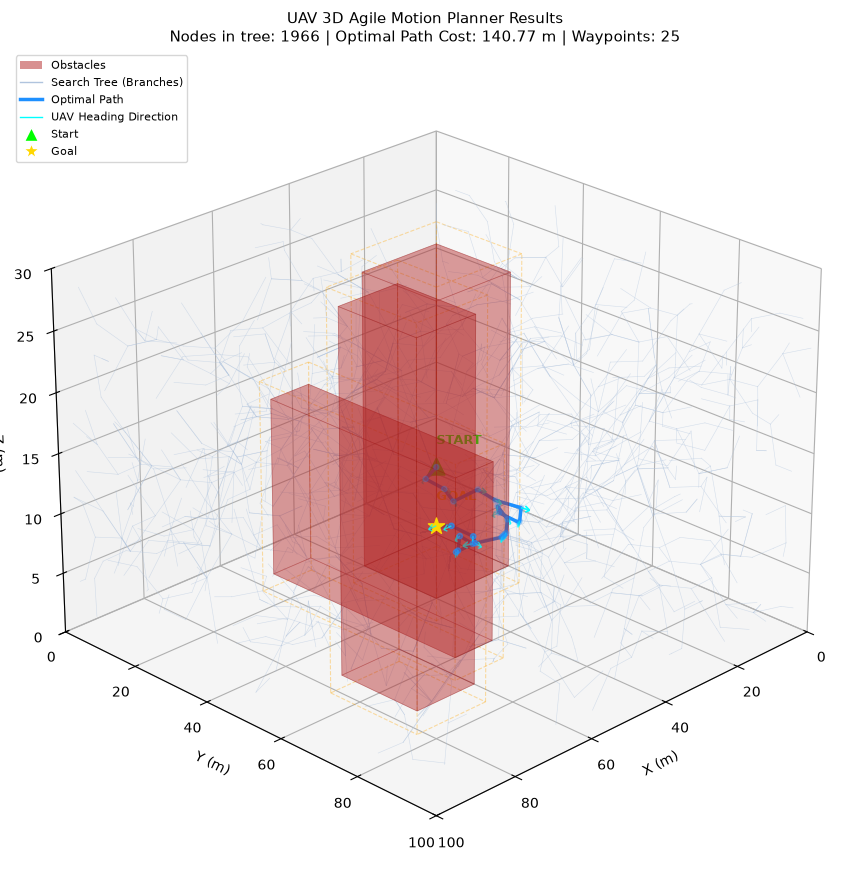

In [14]:
# Initialize Start and Goal nodes
start_node = Node(*START_POS, psi=START_PSI)
goal_node  = Node(*GOAL_POS,  psi=0.0)

print("🚀 Running Agile Motion Planner...")
print(f"   Start : {start_node}")
print(f"   Goal  : {goal_node}\n")

# Run algorithm
node_list, path = plan_rrt_star(start_node, goal_node, seed=None, verbose=True)

# 3D Visualizer
fig = plt.figure(figsize=(13, 9))
ax  = fig.add_subplot(111, projection='3d')

# Draw Obstacles and Safety Buffers
for obs in OBSTACLES:
    draw_cuboid(ax, obs, color='firebrick', alpha=0.25)
    draw_inflated_cuboid(ax, obs)

# Draw RRT Tree Branches
for node in node_list:
    if node.parent is not None:
        ax.plot(
            [node.x, node.parent.x],
            [node.y, node.parent.y],
            [node.z, node.parent.z],
            color='lightsteelblue', linewidth=0.4, alpha=0.5
        )

# Draw Planned Path and Orientation Vector arrows
if path is not None:
    px = [p[0] for p in path]
    py = [p[1] for p in path]
    pz = [p[2] for p in path]
    ax.plot(px, py, pz, color='dodgerblue', linewidth=2.5,
            label=f'Optimal Path ({len(path)} wp)', zorder=5)

    # Plot heading direction vectors at each waypoint
    path_set = set(path)
    for node in node_list:
        if (node.x, node.y, node.z) in path_set and node.parent is not None:
            arrow_len = 2.0
            u = arrow_len * math.cos(node.psi)
            v = arrow_len * math.sin(node.psi)
            w = 0.0
            ax.quiver(node.x, node.y, node.z, u, v, w,
                      length=1.0, color='cyan', arrow_length_ratio=0.5,
                      linewidth=1.0, alpha=0.7)

    # Draw waypoint coordinates
    ax.scatter(px[1:-1], py[1:-1], pz[1:-1], c='dodgerblue', s=15, zorder=6, alpha=0.8)

# Start and Goal markers
sx, sy, sz = START_POS
gx, gy, gz = GOAL_POS
ax.scatter([sx], [sy], [sz], c='lime',  s=150, zorder=10, marker='^')
ax.scatter([gx], [gy], [gz], c='gold',  s=150, zorder=10, marker='*')
ax.text(sx, sy, sz + 2, 'START', fontsize=9, color='lime', fontweight='bold')
ax.text(gx, gy, gz + 2, 'GOAL',  fontsize=9, color='gold', fontweight='bold')

# Axis limits and legend
ax.set_xlim(0, X_MAX); ax.set_ylim(0, Y_MAX); ax.set_zlim(0, Z_MAX)
ax.set_xlabel('X (m)'); ax.set_ylabel('Y (m)'); ax.set_zlabel('Z (m)')
ax.set_title(
    f'UAV 3D Agile Motion Planner Results\n'
    f'Nodes in tree: {len(node_list)} | '
    f'Optimal Path Cost: {node_list[-1].cost:.2f} m | '
    f'Waypoints: {len(path) if path else 0}',
    fontsize=11
)

legend_elements = [
    mpatches.Patch(facecolor='firebrick', alpha=0.5, label='Obstacles'),
    plt.Line2D([0],[0], color='lightsteelblue', linewidth=1,  label='Search Tree (Branches)'),
    plt.Line2D([0],[0], color='dodgerblue',     linewidth=2.5, label='Optimal Path'),
    plt.Line2D([0],[0], color='cyan',           linewidth=1,  label='UAV Heading Direction'),
    plt.Line2D([0],[0], marker='^', color='w', markerfacecolor='lime', markersize=10, label='Start'),
    plt.Line2D([0],[0], marker='*', color='w', markerfacecolor='gold', markersize=12, label='Goal'),
]
ax.legend(handles=legend_elements, loc='upper left', fontsize=8)
ax.view_init(elev=25, azim=45)
plt.tight_layout()
plt.show()

### Trajectory Data Analysis 

In [15]:
if path is None:
    print("❌ Path data not available. Execute Cell 10 first.")
else:
    print("="*75)
    print(" TRAJECTORY ANALYSIS REPORT (Agile Motion Planner)")
    print("="*75)
    print(f"{'WP #':>5} {'X (m)':>8} {'Y (m)':>8} {'Z (m)':>8} {'Heading':>10} {'dYaw':>8} {'dPitch':>8} {'Segment':>8}")
    print("-"*75)

    # Collect path nodes
    def collect_path_nodes(goal_node_ref, all_nodes):
        nodes_on_path = []
        current = goal_node_ref
        while current is not None:
            nodes_on_path.append(current)
            current = current.parent
        nodes_on_path.reverse()
        return nodes_on_path

    path_nodes = collect_path_nodes(node_list[-1], node_list)
    total_dist = 0.0

    for idx, nd in enumerate(path_nodes):
        if idx == 0:
            d_yaw   = 0.0
            d_pitch = 0.0
            d_dist  = 0.0
        else:
            prev = path_nodes[idx - 1]
            d_yaw   = math.degrees(nd.psi) - math.degrees(prev.psi)
            d_yaw   = (d_yaw + 180) % 360 - 180  # Normalize turn angle
            dx = nd.x - prev.x
            dy = nd.y - prev.y
            dz = nd.z - prev.z
            d2d = math.sqrt(dx**2 + dy**2)
            d_pitch = math.degrees(math.atan2(dz, d2d)) if d2d > 1e-6 else 0.0
            d_dist  = hitung_jarak(prev, nd)
            total_dist += d_dist

        tag = " <- START" if idx == 0 else (" <- GOAL" if idx == len(path_nodes)-1 else "")
        print(f"{idx+1:>5} {nd.x:>8.2f} {nd.y:>8.2f} {nd.z:>8.2f} "
              f"{math.degrees(nd.psi):>9.1f}° {d_yaw:>+7.1f}° {d_pitch:>+7.1f}° "
              f"{d_dist:>7.2f}m{tag}")

    print("-"*75)
    print(f"{'Total Path Cost:':>65} {total_dist:>7.2f}m")
    
    # Straight-line baseline
    s = path_nodes[0]
    g = path_nodes[-1]
    straight = math.sqrt((g.x-s.x)**2 + (g.y-s.y)**2 + (g.z-s.z)**2)
    print(f"  📏 Straight Line Distance (Start->Goal) : {straight:.2f} m")
    print(f"  📏 Actual Trajectory Flight Path       : {total_dist:.2f} m")
    print(f"  📊 Path Efficiency                     : {straight/total_dist*100:.1f}%")

 TRAJECTORY ANALYSIS REPORT (Agile Motion Planner)
 WP #    X (m)    Y (m)    Z (m)    Heading     dYaw   dPitch  Segment
---------------------------------------------------------------------------
    1     5.00     5.00     2.00      45.0°    +0.0°    +0.0°    0.00m <- START
    2     9.18     9.18     3.04      45.0°    +0.0°   +10.0°    6.00m
    3    14.66    11.62     3.04      24.0°   -21.0°    +0.0°    6.00m
    4    15.34    17.58     3.04      83.5°   +59.5°    +0.0°    6.00m
    5    18.11    22.90     3.04      62.5°   -21.0°    +0.0°    6.00m
    6    17.01    28.56     4.70     101.0°   +38.5°   +16.0°    6.00m
    7    18.05    34.47     4.70      80.0°   -21.0°    +0.0°    6.00m
    8    16.91    40.36     4.70     101.0°   +21.0°    +0.0°    6.00m
    9    21.40    44.34     4.70      41.5°   -59.5°    +0.0°    6.00m
   10    25.82    48.25     5.74      41.5°    +0.0°   +10.0°    6.00m
   11    31.58    48.56     7.39       3.0°   -38.5°   +16.0°    6.00m
   12    35.

### Parameter Experimentation: Impact on Yaw Bounds

🔬 Experiment: Effect of Turn-Rate Bounds on Flight Path Quality
  Max Yaw ≤  15° | Tree Nodes: 1699 | Waypoints:  25 | Cost:  142.77m | Time: 1.23s  ✅ SUCCESS
  Max Yaw ≤  25° | Tree Nodes: 1937 | Waypoints:  25 | Cost:  139.01m | Time: 1.42s  ✅ SUCCESS
  Max Yaw ≤  35° | Tree Nodes: 1980 | Waypoints:  25 | Cost:  140.59m | Time: 1.63s  ✅ SUCCESS
  Max Yaw ≤  45° | Tree Nodes: 2001 | Waypoints:  26 | Cost:  148.62m | Time: 1.50s  ✅ SUCCESS
  Max Yaw ≤  60° | Tree Nodes: 1993 | Waypoints:  27 | Cost:  153.25m | Time: 1.69s  ✅ SUCCESS



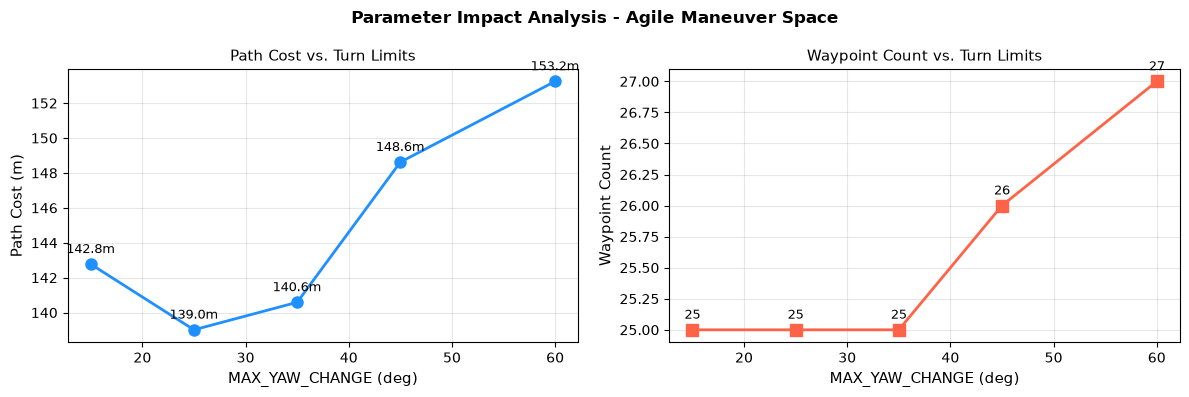

In [16]:
print("🔬 Experiment: Effect of Turn-Rate Bounds on Flight Path Quality")
print("="*75)

yaw_values_deg = [15, 25, 35, 45, 60]  # Different max yaw changes to test
results        = []

for yaw_deg in yaw_values_deg:
    # Temporarily override global parameters
    MAX_YAW_CHANGE_BACKUP = MAX_YAW_CHANGE
    MAX_YAW_CHANGE = math.radians(yaw_deg)

    s = Node(*START_POS, psi=START_PSI)
    g = Node(*GOAL_POS)

    t0 = time.time()
    nl, p = plan_rrt_star(s, g, seed=42, verbose=False)
    elapsed = time.time() - t0

    if p is not None:
        cost = nl[-1].cost
        results.append((yaw_deg, len(nl), len(p), cost, elapsed, True))
        print(f"  Max Yaw ≤ {yaw_deg:>3}° | Tree Nodes: {len(nl):>4} | "
              f"Waypoints: {len(p):>3} | Cost: {cost:>7.2f}m | Time: {elapsed:.2f}s  ✅ SUCCESS")
    else:
        results.append((yaw_deg, len(nl), 0, float('inf'), elapsed, False))
        print(f"  Max Yaw ≤ {yaw_deg:>3}° | Tree Nodes: {len(nl):>4} | "
              f"Waypoints:   - | Cost:    FAILED | Time: {elapsed:.2f}s  ❌ FAILED")

    MAX_YAW_CHANGE = MAX_YAW_CHANGE_BACKUP  # Restore backup parameter

print()

# Plot experimental data
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
yaw_list  = [r[0] for r in results if r[5]]
cost_list = [r[3] for r in results if r[5]]
wp_list   = [r[2] for r in results if r[5]]

if len(cost_list) > 0:
    axes[0].plot(yaw_list, cost_list, 'o-', color='dodgerblue', linewidth=2, markersize=8)
    axes[0].set_xlabel('MAX_YAW_CHANGE (deg)', fontsize=11)
    axes[0].set_ylabel('Path Cost (m)', fontsize=11)
    axes[0].set_title('Path Cost vs. Turn Limits', fontsize=11)
    axes[0].grid(True, alpha=0.3)
    for x, y in zip(yaw_list, cost_list):
        axes[0].annotate(f'{y:.1f}m', (x, y), textcoords='offset points', xytext=(0, 8), ha='center', fontsize=9)

    axes[1].plot(yaw_list, wp_list, 's-', color='tomato', linewidth=2, markersize=8)
    axes[1].set_xlabel('MAX_YAW_CHANGE (deg)', fontsize=11)
    axes[1].set_ylabel('Waypoint Count', fontsize=11)
    axes[1].set_title('Waypoint Count vs. Turn Limits', fontsize=11)
    axes[1].grid(True, alpha=0.3)
    for x, y in zip(yaw_list, wp_list):
        axes[1].annotate(str(y), (x, y), textcoords='offset points', xytext=(0, 8), ha='center', fontsize=9)

plt.suptitle('Parameter Impact Analysis - Agile Maneuver Space', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

### 2D Orthographic Views (Top View and Side View)

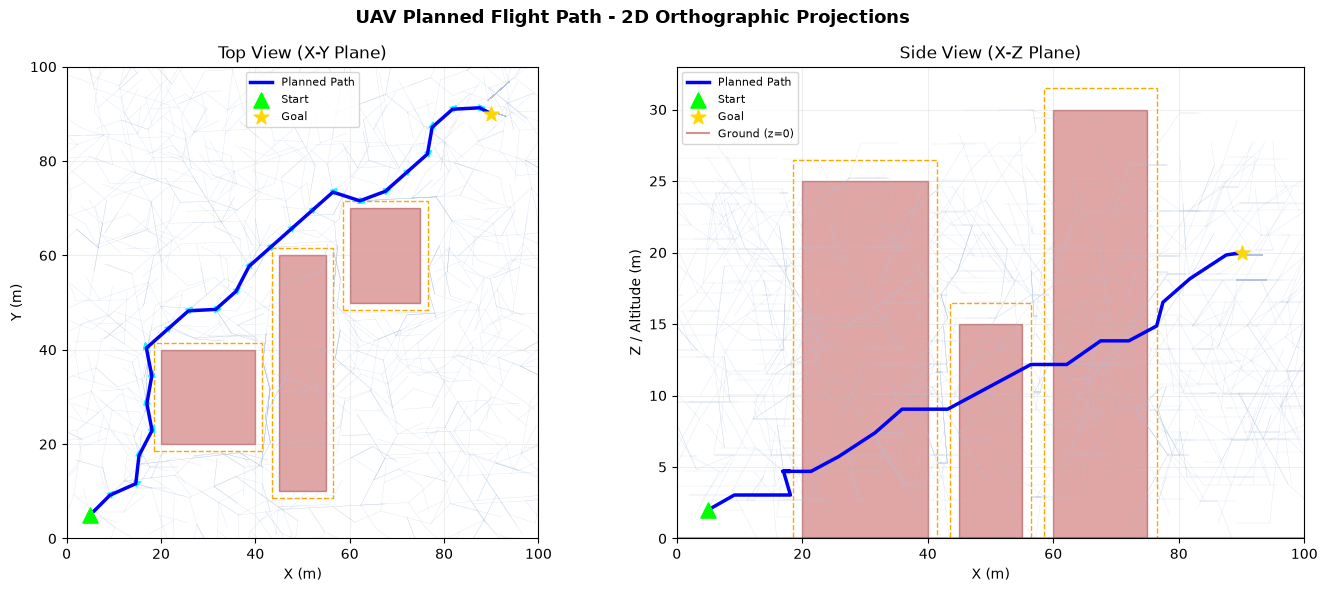

In [17]:
if path is None:
    print("❌ Path data not available. Run Cell 10 first.")
else:
    px = [p[0] for p in path]
    py = [p[1] for p in path]
    pz = [p[2] for p in path]

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # --- TOP VIEW (X-Y Plane Projection) ---
    ax1 = axes[0]
    # Draw tree branches
    for node in node_list:
        if node.parent is not None:
            ax1.plot([node.x, node.parent.x], [node.y, node.parent.y],
                     color='lightsteelblue', linewidth=0.3, alpha=0.4)
    # Draw obstacles in 2D projection
    for obs in OBSTACLES:
        x_min, y_min, _, x_max, y_max, _ = obs
        buf = INFLATION
        rect = plt.Rectangle((x_min, y_min), x_max-x_min, y_max-y_min,
                              linewidth=1, edgecolor='darkred', facecolor='firebrick', alpha=0.4)
        rect_buf = plt.Rectangle((x_min-buf, y_min-buf), x_max-x_min+2*buf, y_max-y_min+2*buf,
                                  linewidth=1, edgecolor='orange', facecolor='none', linestyle='--')
        ax1.add_patch(rect)
        ax1.add_patch(rect_buf)
    # Plot path and nodes
    ax1.plot(px, py, 'b-', linewidth=2.5, label='Planned Path', zorder=5)
    ax1.scatter([px[0]], [py[0]], c='lime', s=120, zorder=6, marker='^', label='Start')
    ax1.scatter([px[-1]], [py[-1]], c='gold', s=120, zorder=6, marker='*', label='Goal')
    
    # Plot vector direction indicators
    for nd in node_list:
        if (nd.x, nd.y, nd.z) in set(path) and nd.parent is not None:
            ax1.annotate('', xy=(nd.x + 2*math.cos(nd.psi), nd.y + 2*math.sin(nd.psi)),
                         xytext=(nd.x, nd.y), arrowprops=dict(arrowstyle='->', color='cyan', lw=1.2))
    
    ax1.set_xlim(0, X_MAX); ax1.set_ylim(0, Y_MAX)
    ax1.set_xlabel('X (m)'); ax1.set_ylabel('Y (m)')
    ax1.set_title('Top View (X-Y Plane)', fontsize=12)
    ax1.legend(fontsize=8); ax1.grid(True, alpha=0.2)
    ax1.set_aspect('equal')

    # --- SIDE VIEW (X-Z Plane Projection) ---
    ax2 = axes[1]
    # Draw tree branches
    for node in node_list:
        if node.parent is not None:
            ax2.plot([node.x, node.parent.x], [node.z, node.parent.z],
                     color='lightsteelblue', linewidth=0.3, alpha=0.4)
    # Draw obstacles in 2D projection
    for obs in OBSTACLES:
        x_min, _, z_min, x_max, _, z_max = obs
        buf = INFLATION
        rect = plt.Rectangle((x_min, z_min), x_max-x_min, z_max-z_min,
                              linewidth=1, edgecolor='darkred', facecolor='firebrick', alpha=0.4)
        rect_buf = plt.Rectangle((x_min-buf, z_min-buf), x_max-x_min+2*buf, z_max-z_min+2*buf,
                                  linewidth=1, edgecolor='orange', facecolor='none', linestyle='--')
        ax2.add_patch(rect)
        ax2.add_patch(rect_buf)
    # Plot path and nodes
    ax2.plot(px, pz, 'b-', linewidth=2.5, label='Planned Path', zorder=5)
    ax2.scatter([px[0]], [pz[0]], c='lime', s=120, zorder=6, marker='^', label='Start')
    ax2.scatter([px[-1]], [pz[-1]], c='gold', s=120, zorder=6, marker='*', label='Goal')
    ax2.axhline(y=0, color='brown', linewidth=1.5, linestyle='-', alpha=0.5, label='Ground (z=0)')
    
    ax2.set_xlim(0, X_MAX); ax2.set_ylim(0, Z_MAX + 3)
    ax2.set_xlabel('X (m)'); ax2.set_ylabel('Z / Altitude (m)')
    ax2.set_title('Side View (X-Z Plane)', fontsize=12)
    ax2.legend(fontsize=8); ax2.grid(True, alpha=0.2)

    plt.suptitle('UAV Planned Flight Path - 2D Orthographic Projections', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()